# Model Evaluation 

### Load features 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import joblib

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

# Load preprocessed splits (created by preprocessing.ipynb)
base = '../data/processed/splits/'
X_train = pd.read_csv(base + 'X_train.csv')
y_train = pd.read_csv(base + 'y_train.csv').squeeze()
X_val   = pd.read_csv(base + 'X_val.csv')
y_val   = pd.read_csv(base + 'y_val.csv').squeeze()
X_test  = pd.read_csv(base + 'X_test.csv')
y_test  = pd.read_csv(base + 'y_test.csv').squeeze()

print('X_train shape:', X_train.shape)
print('X_val shape  :', X_val.shape)
print('X_test shape :', X_test.shape)

# Load class weights if available
class_weights = None
try:
    with open('../outputs/encoders/class_weights.pkl', 'rb') as f:
        class_weights = pickle.load(f)
    print('Loaded class_weights from outputs/encoders/class_weights.pkl')
except Exception:
    print('No class_weights file found; will use balanced/default settings')


X_train shape: (2947008, 12)
X_val shape  : (1044965, 12)
X_test shape : (1044791, 12)
Loaded class_weights from outputs/encoders/class_weights.pkl


### Modeling 

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import joblib

# Determine scale_pos_weight for XGBoost from training labels
n_on_time = (y_train == 0).sum()
n_delayed = (y_train == 1).sum()
scale_pos_weight = max(1, n_on_time / max(1, n_delayed))

models = {
    'Logistic_Regression': LogisticRegression(max_iter=1000, class_weight=class_weights or 'balanced', n_jobs=-1),
    'Random_Forest': RandomForestClassifier(n_estimators=100, max_depth=10, class_weight=class_weights or 'balanced', n_jobs=-1),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_pos_weight, n_jobs=-1)
}

results = {}
os.makedirs('../outputs/models', exist_ok=True)
for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train)
    results[name] = model
    joblib.dump(model, f'../outputs/models/{name}.pkl')
    print(f'Saved model: ../outputs/models/{name}.pkl')


Training Logistic_Regression...


c:\Users\mtawa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Saved model: ../outputs/models/Logistic_Regression.pkl
Training Random_Forest...
Saved model: ../outputs/models/Random_Forest.pkl
Training XGBoost...


c:\Users\mtawa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:12:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Saved model: ../outputs/models/XGBoost.pkl


### Evaluation 

                 Model  Val_Accuracy  Val_F1_Delayed  Val_ROC_AUC  \
2              XGBoost        0.6482          0.4245       0.7015   
1        Random_Forest        0.3194          0.3603       0.6741   
0  Logistic_Regression        0.2723          0.3474       0.6253   

   Test_Accuracy  Test_F1_Delayed  Test_ROC_AUC  
2         0.6481           0.4241        0.7016  
1         0.3192           0.3602        0.6742  
0         0.2724           0.3473        0.6259  
Best model by Test ROC_AUC: XGBoost


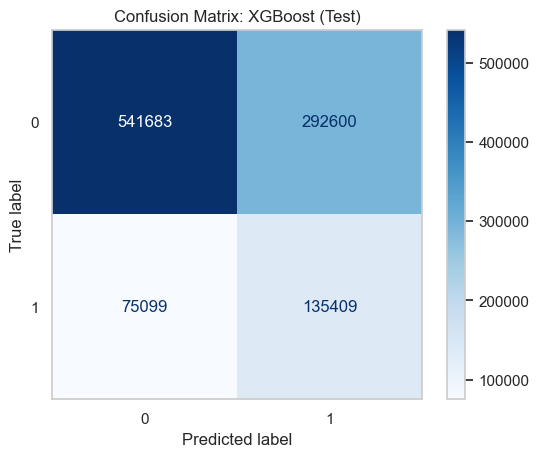

In [6]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, ConfusionMatrixDisplay

performance_summary = []

for name, model in results.items():
    # Validation metrics
    y_val_pred = model.predict(X_val)
    y_val_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, 'predict_proba') else model.predict(X_val)
    val_report = classification_report(y_val, y_val_pred, output_dict=True)
    val_auc = roc_auc_score(y_val, y_val_proba) if len(set(y_val))>1 else None

    # Test metrics
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else model.predict(X_test)
    test_report = classification_report(y_test, y_test_pred, output_dict=True)
    test_auc = roc_auc_score(y_test, y_test_proba) if len(set(y_test))>1 else None

    performance_summary.append({
        'Model': name,
        'Val_Accuracy': val_report['accuracy'],
        'Val_F1_Delayed': val_report['1']['f1-score'],
        'Val_ROC_AUC': val_auc,
        'Test_Accuracy': test_report['accuracy'],
        'Test_F1_Delayed': test_report['1']['f1-score'],
        'Test_ROC_AUC': test_auc
    })

perf_df = pd.DataFrame(performance_summary).sort_values(by='Test_ROC_AUC', ascending=False)
print(perf_df.round(4))

# Visualize confusion matrix for best model on test set
best_model_name = perf_df.iloc[0]['Model']
print(f'Best model by Test ROC_AUC: {best_model_name}')
ConfusionMatrixDisplay.from_estimator(results[best_model_name], X_test, y_test, cmap='Blues')
plt.title(f'Confusion Matrix: {best_model_name} (Test)')
plt.grid(False)
plt.show()


In [4]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 6, 10],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__subsample': [0.8, 1.0],
    'classifier__scale_pos_weight': [scale_pos_weight]
}

xgb_pipeline = Pipeline(steps=[
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

tuned_xgb = RandomizedSearchCV(
    xgb_pipeline, 
    param_distributions=param_grid, 
    n_iter=5, 
    scoring='roc_auc', 
    cv=3, 
    verbose=1, 
    random_state=42
)

print('Starting Hyperparameter Tuning on XGBoost...')
tuned_xgb.fit(X_train, y_train)

print('Best Parameters:', tuned_xgb.best_params_)
print('Best ROC-AUC:', tuned_xgb.best_score_)

joblib.dump(tuned_xgb.best_estimator_, '../outputs/models/XGBoost_tuned.pkl')
print('Saved tuned XGBoost to ../outputs/models/XGBoost_tuned.pkl')


Starting Hyperparameter Tuning on XGBoost...
Fitting 3 folds for each of 5 candidates, totalling 15 fits


c:\Users\mtawa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:16:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\mtawa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:16:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\mtawa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:16:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\mtawa\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:17:11] WARNING: C:\actio

Best Parameters: {'classifier__subsample': 0.8, 'classifier__scale_pos_weight': np.float64(2.0), 'classifier__n_estimators': 200, 'classifier__max_depth': 6, 'classifier__learning_rate': 0.1}
Best ROC-AUC: 0.6977042933084764
Saved tuned XGBoost to ../outputs/models/XGBoost_tuned.pkl


C:\Users\mtawa\AppData\Local\Temp\ipykernel_3220\1130377536.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


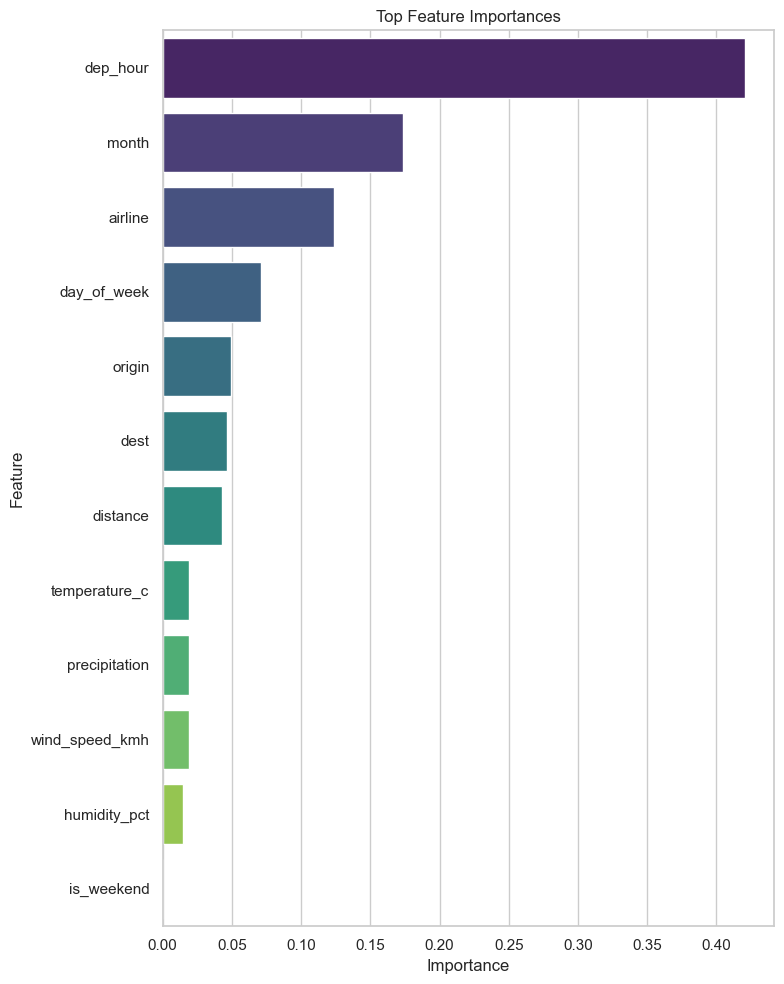

Saved final model to ../outputs/models/final_model.pkl


In [5]:
# Use tuned XGBoost if available, otherwise fallback to trained XGBoost
final_model = tuned_xgb.best_estimator_ if 'tuned_xgb' in globals() else results.get('XGBoost')

# Extract feature importance
if hasattr(final_model.named_steps['classifier'], 'feature_importances_'):
    importance = final_model.named_steps['classifier'].feature_importances_
    feature_names = X_train.columns
    feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance}).sort_values('Importance', ascending=False).head(20)
    plt.figure(figsize=(8,10))
    sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
    plt.title('Top Feature Importances')
    plt.tight_layout()
    plt.show()
else:
    print('Final model does not expose feature_importances_; skipping plot')

# Save final model
joblib.dump(final_model, '../outputs/models/final_model.pkl')
print('Saved final model to ../outputs/models/final_model.pkl')
